In [3]:
import pandas as pd
import numpy as np

# Load your merged dataset
df = pd.read_csv("merged_exoplanets.csv")

# Keep only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Compute correlation matrix
corr = numeric_df.corr()

# Sort correlation of all features with the target label
print(corr['disposition'].sort_values(ascending=False))


disposition         1.000000
stellar_gravity     0.171076
orbital_period     -0.008569
planet_radius      -0.022176
insolation_flux    -0.043690
stellar_radius     -0.085993
transit_duration   -0.148485
stellar_temp       -0.176006
transit_depth      -0.231575
eq_temperature     -0.277319
Name: disposition, dtype: float64


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# Drop rows where target is missing
df = df.dropna(subset=['disposition'])


# Prepare data
X = df.drop(columns=['disposition', 'planet_name', 'source'])
X = X.select_dtypes(include=[np.number]).fillna(0)
y = df['disposition']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Get feature importances
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)

planet_radius       0.197267
transit_depth       0.159919
orbital_period      0.114667
transit_duration    0.114175
insolation_flux     0.096162
eq_temperature      0.084729
stellar_temp        0.080718
stellar_gravity     0.077514
stellar_radius      0.074848
dtype: float64


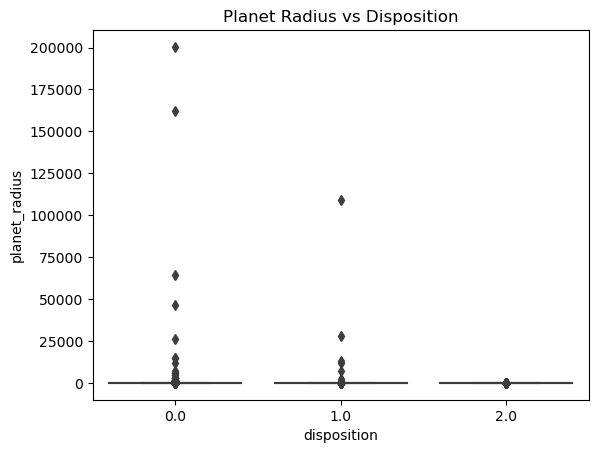

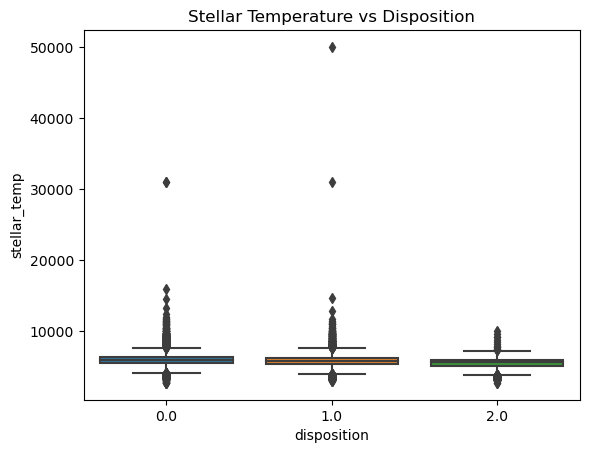

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='disposition', y='planet_radius', data=df)
plt.title("Planet Radius vs Disposition")
plt.show()

sns.boxplot(x='disposition', y='stellar_temp', data=df)
plt.title("Stellar Temperature vs Disposition")
plt.show()

✅ Data loaded and cleaned
Number of numeric features: 9
Disposition classes: [2 1 0]


/tmp/ipykernel_457187/2319411119.py:56: UserWarning: Glyph 128293 (\N{FIRE}) missing from current font.
  plt.tight_layout()
/srv/jupyter_python3-extra/lib/python3.10/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


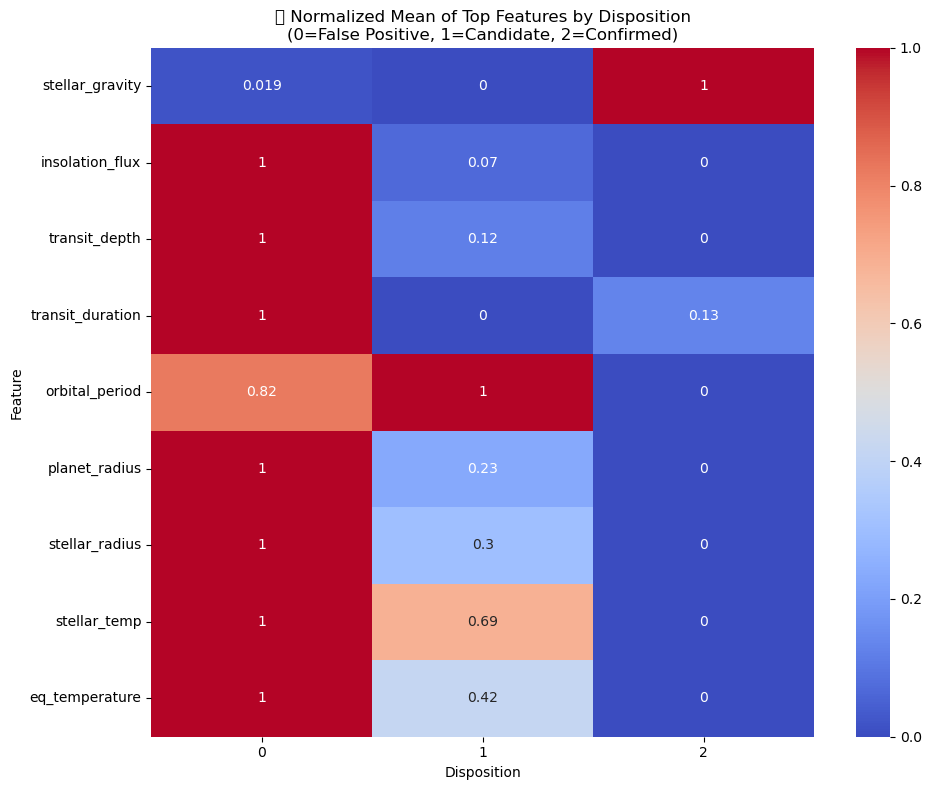


🔍 Top 10 most influential features:
                  Class_0_FalsePositive  Class_1_Candidate  Class_2_Confirmed  \
transit_depth                  1.419502          -0.583931          -5.110873   
orbital_period                 0.011000           0.533751          -6.506524   
insolation_flux                1.717298          -3.309643          -1.514997   
planet_radius                  0.050547          -0.018339          -3.779478   
eq_temperature                 0.776823          -0.217772          -1.111361   
transit_duration               0.770650          -0.569345          -0.122395   
stellar_gravity               -0.078029          -0.287109           0.962899   
stellar_temp                  -0.308125           0.318991          -0.044451   
stellar_radius                -0.015981          -0.005477           0.170152   

                  importance  
transit_depth       7.114306  
orbital_period      7.051276  
insolation_flux     6.541937  
planet_radius       3.848364

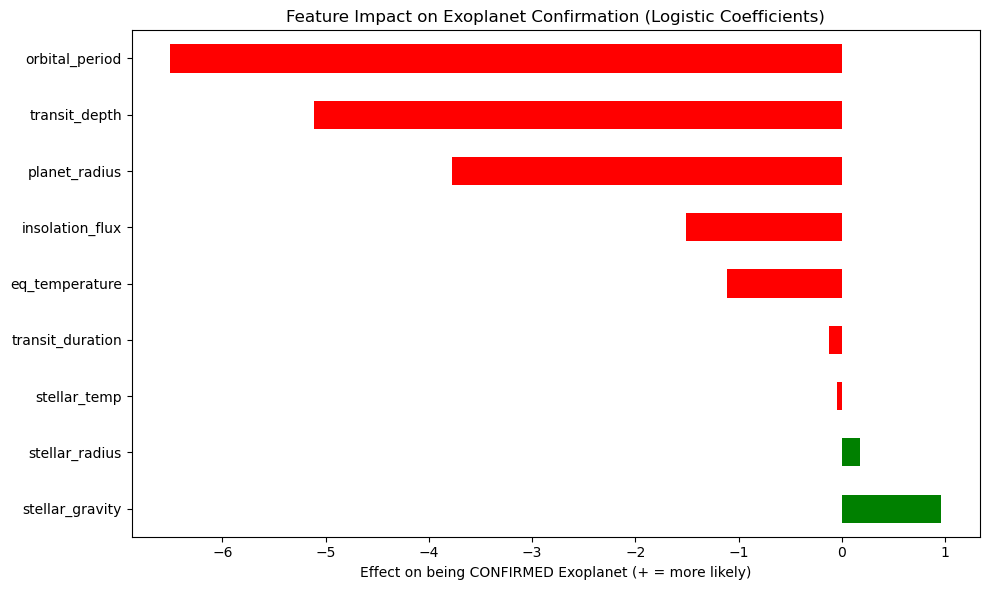


🌟 Combined feature importance ranking:
                  variance_across_classes  importance_from_logit  score
stellar_radius                   0.262862               0.191611   16.0
stellar_temp                     0.261546               0.671567   16.0
eq_temperature                   0.252325               2.105956   14.0
planet_radius                    0.273806               3.848364   10.0
transit_duration                 0.295307               1.462390   10.0
stellar_gravity                  0.327160               1.328037    8.0
orbital_period                   0.284862               7.051276    7.0
insolation_flux                  0.311592               6.541937    5.0
transit_depth                    0.298593               7.114306    4.0

🗑️ Suggested features to drop:
['insolation_flux', 'transit_depth']


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# -------------------------------
# 1. Load & clean data
# -------------------------------
df = pd.read_csv("merged_exoplanets.csv")

# Drop rows without known disposition
df = df.dropna(subset=['disposition'])

# Encode textual disposition into numeric categories
if df['disposition'].dtype == object:
    df['disposition'] = df['disposition'].map({
        'FALSE POSITIVE': 0,
        'CANDIDATE': 1,
        'CONFIRMED': 2
    })

# Ensure numeric + drop invalid rows
df['disposition'] = pd.to_numeric(df['disposition'], errors='coerce')
df = df.dropna(subset=['disposition'])
df['disposition'] = df['disposition'].astype(int)

# Keep only numeric columns (features)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'disposition']

# Final numeric dataset
df_num = df[numeric_cols + ['disposition']].fillna(0)

print("✅ Data loaded and cleaned")
print("Number of numeric features:", len(numeric_cols))
print("Disposition classes:", df['disposition'].unique())

# -------------------------------
# 2. Explore feature relationships
# -------------------------------
group_means = df_num.groupby('disposition').mean()
group_means_norm = group_means.apply(lambda x: (x - x.min()) / (x.max() - x.min()), axis=0)

# Measure how features differ between disposition classes
variance = group_means_norm.var().sort_values(ascending=False)
top_features = variance.head(15).index

# --- Visualize ---
plt.figure(figsize=(10, 8))
sns.heatmap(group_means_norm[top_features].T, annot=True, cmap="coolwarm")
plt.title("🔥 Normalized Mean of Top Features by Disposition\n(0=False Positive, 1=Candidate, 2=Confirmed)")
plt.ylabel("Feature")
plt.xlabel("Disposition")
plt.tight_layout()
plt.show()

# -------------------------------
# 3. Logistic regression interpretability
# -------------------------------
X = df_num[numeric_cols]
y = df_num['disposition']

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Multiclass logistic regression (one-vs-rest)
log_reg = LogisticRegression(max_iter=1000, multi_class='ovr')
log_reg.fit(X_scaled, y)

# Coefficients per class
coef_df = pd.DataFrame(
    log_reg.coef_.T,
    index=numeric_cols,
    columns=['Class_0_FalsePositive', 'Class_1_Candidate', 'Class_2_Confirmed']
)

# Compute total importance
coef_df['importance'] = coef_df.abs().sum(axis=1)
coef_df = coef_df.sort_values('importance', ascending=False)

print("\n🔍 Top 10 most influential features:")
print(coef_df.head(10))

# -------------------------------
# 4. Visualize effect on CONFIRMED
# -------------------------------
plt.figure(figsize=(10, 6))
coef_df_sorted = coef_df.sort_values("Class_2_Confirmed", ascending=False).head(20)
coef_df_sorted["Class_2_Confirmed"].plot(kind="barh", color=np.where(coef_df_sorted["Class_2_Confirmed"] > 0, 'green', 'red'))
plt.xlabel("Effect on being CONFIRMED Exoplanet (+ = more likely)")
plt.title("Feature Impact on Exoplanet Confirmation (Logistic Coefficients)")
plt.tight_layout()
plt.show()

# -------------------------------
# 5. Combine variance + logistic importance
# -------------------------------
combined = pd.DataFrame({
    'variance_across_classes': variance,
    'importance_from_logit': coef_df['importance']
}).fillna(0)

combined['score'] = (combined['variance_across_classes'].rank(ascending=False) +
                     combined['importance_from_logit'].rank(ascending=False))
combined = combined.sort_values('score', ascending=False)

print("\n🌟 Combined feature importance ranking:")
print(combined.head(20))

# Identify potential useless features
threshold = combined['score'].quantile(0.2)  # bottom 20%
useless_features = combined[combined['score'] < threshold].index.tolist()
print("\n🗑️ Suggested features to drop:")
print(useless_features)



🌳 Random Forest Feature Importance (non-linear relationships):
planet_radius       0.196846
transit_depth       0.159205
transit_duration    0.115777
orbital_period      0.113407
insolation_flux     0.093733
eq_temperature      0.086741
stellar_temp        0.080963
stellar_gravity     0.078359
stellar_radius      0.074968
dtype: float64


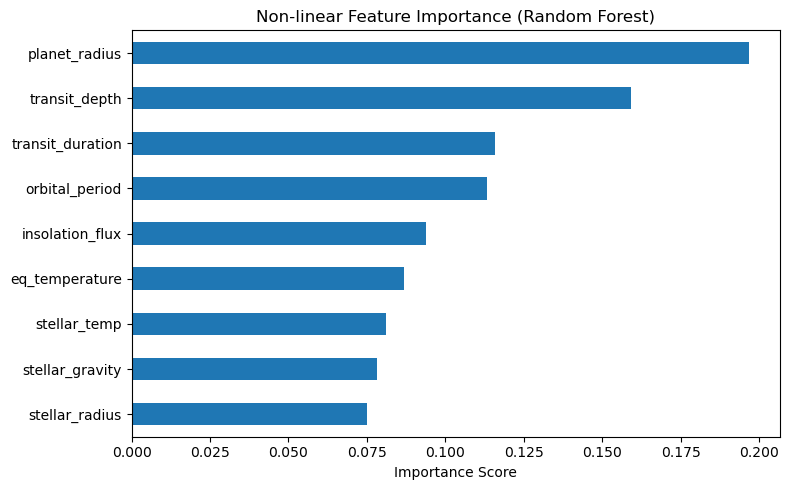

In [13]:
from sklearn.ensemble import RandomForestClassifier

# Prepare data
X = df_num[numeric_cols]
y = df_num['disposition']

# Train a random forest (captures non-linear patterns)
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X, y)

# Get non-linear feature importance
rf_importance = pd.Series(rf.feature_importances_, index=numeric_cols).sort_values(ascending=False)

print("\n🌳 Random Forest Feature Importance (non-linear relationships):")
print(rf_importance.head(10))

# Visualize
plt.figure(figsize=(8, 5))
rf_importance.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Non-linear Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()


In [18]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer

# ------------------------------------------
# 1️⃣ Load your dataset
# ------------------------------------------
df = pd.read_csv("merged_exoplanets.csv")

# Encode the disposition labels (e.g., Confirmed, Candidate, False Positive)
le = LabelEncoder()
df["disposition_encoded"] = le.fit_transform(df["disposition"])

# ------------------------------------------
# 2️⃣ Select numeric columns
# ------------------------------------------
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Remove the target column from numeric features
numeric_cols = [c for c in numeric_cols if c != "disposition_encoded"]

# ------------------------------------------
# 3️⃣ Handle missing values using median imputation
# ------------------------------------------
imputer = SimpleImputer(strategy="median")
X = pd.DataFrame(imputer.fit_transform(df[numeric_cols]), columns=numeric_cols)
y = df["disposition_encoded"]

# ------------------------------------------
# 4️⃣ Compute correlation with target (linear)
# ------------------------------------------
correlations = []
for col in numeric_cols:
    corr = np.corrcoef(X[col], y)[0, 1]
    correlations.append(abs(corr))  # take absolute correlation

correlations = pd.Series(correlations, index=numeric_cols)

# ------------------------------------------
# 5️⃣ Random Forest (non-linear) feature importance
# ------------------------------------------
rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)
importances = pd.Series(rf.feature_importances_, index=numeric_cols)

# ------------------------------------------
# 6️⃣ Combine both correlation & importance
# ------------------------------------------
feature_scores = pd.DataFrame({
    "Correlation": correlations,
    "Importance": importances
}).fillna(0)

# Normalize each to compare on same scale
feature_scores["Correlation_norm"] = feature_scores["Correlation"] / feature_scores["Correlation"].max()
feature_scores["Importance_norm"] = feature_scores["Importance"] / feature_scores["Importance"].max()

# Weighted combination (tweak weights if you want)
feature_scores["Combined_Score"] = (
    0.4 * feature_scores["Correlation_norm"] +
    0.6 * feature_scores["Importance_norm"]
)

# Sort by combined score (higher = more influential)
feature_scores_sorted = feature_scores.sort_values("Combined_Score", ascending=False)

print("🔍 Top features by combined score:\n")
print(feature_scores_sorted)

# ------------------------------------------
# 7️⃣ Select top features and save new CSV
# ------------------------------------------
top_features = feature_scores_sorted.head(7).index.tolist()  # top 7
df_selected = df[top_features + ["disposition"]]
df_selected.to_csv("selected_features.csv", index=False)

print("\n✅ Saved top 7 features to 'selected_features.csv'")
print("🧠 Top features kept:", top_features)


🔍 Top features by combined score:

                  Correlation  Importance  Correlation_norm  Importance_norm  \
disposition          0.669226    0.561024          1.000000         1.000000   
transit_depth        0.216517    0.135252          0.323533         0.241081   
transit_duration     0.188834    0.110273          0.282168         0.196556   
eq_temperature       0.216336    0.034514          0.323263         0.061520   
stellar_temp         0.190626    0.011614          0.284845         0.020701   
stellar_gravity      0.176766    0.009030          0.264135         0.016096   
insolation_flux      0.039792    0.050539          0.059460         0.090083   
planet_radius        0.021298    0.053809          0.031824         0.095912   
stellar_radius       0.074692    0.011337          0.111609         0.020208   
orbital_period       0.008666    0.022607          0.012949         0.040297   

                  Combined_Score  
disposition             1.000000  
transit_depth 

In [20]:
import pandas as pd

# Load dataset
df = pd.read_csv("merged_exoplanets.csv")

# --- 1️⃣ Identify ID and label columns ---
id_columns = [col for col in df.columns if "id" in col.lower() or "name" in col.lower()]
print("ID columns detected:", id_columns)

# --- 2️⃣ Keep scientifically useful features (based on your analysis) ---
useful_features = [
    "transit_depth",
    "transit_duration",
    "eq_temperature",
    "insolation_flux",
    "planet_radius",
    "stellar_temp"
]

# --- 3️⃣ Always include target label ---
target = ["disposition"]

# --- 4️⃣ Combine everything you want to keep ---
columns_to_keep = id_columns + useful_features + target
columns_to_keep = [col for col in columns_to_keep if col in df.columns]  # safety check

# --- 5️⃣ Create clean dataset ---
df_selected = df[columns_to_keep].dropna()

# --- 6️⃣ Save the cleaned version ---
df_selected.to_csv("exoplanet_selected_features.csv", index=False)

print("✅ New dataset created with:")
print(df_selected.columns.tolist())
print("\n💾 Saved as: exoplanet_selected_features.csv")
print(df_selected.head())


ID columns detected: ['planet_name']
✅ New dataset created with:
['planet_name', 'transit_depth', 'transit_duration', 'eq_temperature', 'insolation_flux', 'planet_radius', 'stellar_temp', 'disposition']

💾 Saved as: exoplanet_selected_features.csv
    planet_name  transit_depth  transit_duration  eq_temperature  \
0  Kepler-227 b          615.8            2.9575           793.0   
1  Kepler-227 c          874.8            4.5070           443.0   
4  Kepler-664 b          603.3            1.6545          1406.0   
5  Kepler-228 d         1517.5            4.5945           835.0   
6  Kepler-228 c          686.0            3.1402          1160.0   

   insolation_flux  planet_radius  stellar_temp  disposition  
0            93.59           2.26        5455.0          2.0  
1             9.11           2.83        5455.0          2.0  
4           926.16           2.75        6031.0          2.0  
5           114.81           3.90        6046.0          2.0  
6           427.65          